### Nicola Bianchetti: nicola.bianchetti@unimi.it


### Ufficio 1° piano sezione astrofisica

##### Nootebooks sviluppati con l'aiuto di Davide Abriola

### Python tutorial: https://www.w3schools.com/python/default.asp
### Anaconda download: https://www.anaconda.com/download

## ________________________________ Lezione 4  ________________________________

#### Riproducibilità dei risultati

Tipicamente, è fondamentale essere in grado di ripetere le misure e riottenere gli stessi risultati dagli stessi dati. Per farlo, si può ricorrere ai `seed`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

plt.rcParams.update({"font.size":14})

In [3]:
#plt.rcParams.keys()

In [4]:
np.random.seed(42) #imposto il seed delle prossime operazioni "randomiche"

In [5]:
np.random.rand(4)

array([0.37454012, 0.95071431, 0.73199394, 0.59865848])

In [6]:
np.random.rand(4)

array([0.15601864, 0.15599452, 0.05808361, 0.86617615])

In [7]:
np.random.seed(42)
np.random.rand(4) #riottengo il primo risultato!

array([0.37454012, 0.95071431, 0.73199394, 0.59865848])

#### SciPy

Per problemi di ottimizzazione, integrazione, interpolazione e tutto ciò che riguarda il calcolo computazionale, `SciPy` è la libreria di riferimento. Si intreccia facilmente con `NumPy`, permettendo di approfondire i metodi matematici su array e dati in generale.

##### Fit di curve

In [8]:
from scipy.optimize import curve_fit

In [9]:
np.random.seed(42)

t = np.linspace(0, 10, 50)
true_slope = 2.5
true_intercept = 1.0

noise = np.random.normal(0, 2, size=len(t))
v = true_slope * t + true_intercept + noise #genero dati con rumore randomico

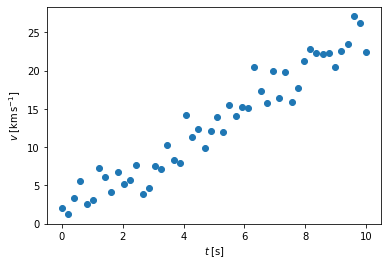

In [10]:
plt.scatter(t, v)
plt.xlabel("$t \; \mathrm{[s]}$")
plt.ylabel("$v \; \mathrm{[km\,s^{-1}]}$")
plt.show() #Comportamento lineare?

In [11]:
def linear_model(x, m, b):
    return m * x + b

In [12]:
params, covariance = curve_fit(linear_model, t, v) #stiamo stimando i parametri dai dati!

m_fit, b_fit = params
print("Pendenza:", round(m_fit,2))
print("Intercetta:", round(b_fit,2))

Pendenza: 2.38
Intercetta: 1.13


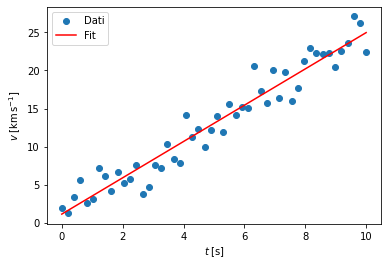

In [13]:
x_model = np.linspace(0, 10, 100)
y_model = linear_model(x_model, m_fit, b_fit)

plt.scatter(t, v, label="Dati")
plt.plot(x_model, y_model, label="Fit", color='red')
plt.xlabel("$t \; \mathrm{[s]}$")
plt.ylabel("$v \; \mathrm{[km\,s^{-1}]}$")
plt.legend()
plt.show()

In [14]:
#otteniamo anche le incertezze dalla matrice di covarianza!
errors = np.sqrt(np.diag(covariance))
print("Incertezza pendenza:", round(errors[0],2))
print("Incertezza intercetta:", round(errors[1],2))

Incertezza pendenza: 0.09
Incertezza intercetta: 0.52


In [15]:
#confronto finale
print("Pendenza:", round(m_fit,2), r"$\pm$", round(errors[0],2), "| Valore reale:", true_slope)
print("Intercetta:", round(b_fit,2), r"$\pm$", round(errors[1],2), "| Valore reale:", true_intercept)

Pendenza: 2.38 $\pm$ 0.09 | Valore reale: 2.5
Intercetta: 1.13 $\pm$ 0.52 | Valore reale: 1.0


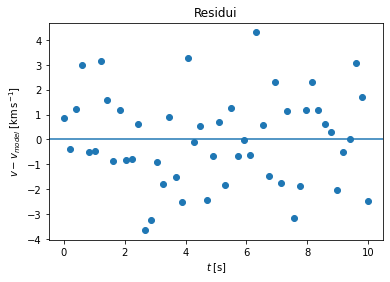

In [16]:
#Analizziamo i residui
residuals = v - linear_model(t, m_fit, b_fit)

plt.scatter(t, residuals)
plt.axhline(0) #I residui devono fluttuare in modo randomico attorno allo 0 perchè il modello possa essere ritenuto 'corretto'
plt.xlabel("$t \; \mathrm{[s]}$")
plt.ylabel("$v - v_{model}\;\mathrm{[km\,s^{-1}]}$")
plt.title("Residui")
plt.show()

##### Distribuzioni di probabilità
Primo concetto fondamentale per l'utilizzo delle catene di Markov

In [18]:
from scipy import stats

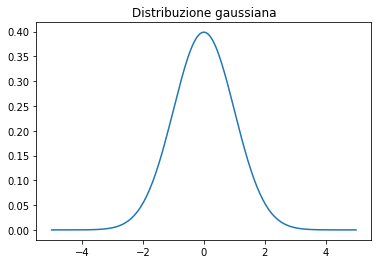

In [21]:
x = np.linspace(-5, 5, 200)
pdf = stats.norm.pdf(x, 0, 1)
#print(pdf)
plt.plot(x, pdf)
plt.title("Distribuzione gaussiana") #Generare rumore gaussiano
plt.show()

##### Interpolare

In [22]:
from scipy.interpolate import interp1d

# Measured data
t = np.array([0, 1, 2, 3, 4, 5])
signal = np.array([0.0, 0.8, 0.9, 0.1, -0.8, -1.0])

In [23]:
interp_func = interp1d(t, signal, kind="cubic") #creo la funzione interpolando, kind indica il tipo di algoritmo usato per svolgere l'interpolazione

In [27]:
t_dense = np.linspace(0, 5, 200) #la valuto su altri punti
signal_interp = interp_func(t_dense)

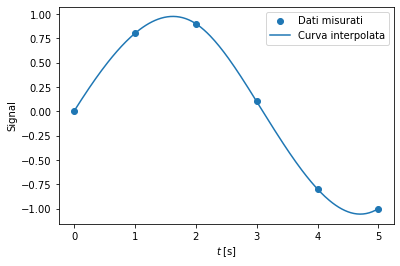

In [28]:
plt.scatter(t, signal, label="Dati misurati")
plt.plot(t_dense, signal_interp, label="Curva interpolata")
plt.xlabel("$t \; \mathrm{[s]}$")
plt.ylabel("Signal") #Funzione continua da misure discrete
plt.legend()
plt.show()

In [32]:
#interp1d?

##### Integrare

In [29]:
from scipy.integrate import quad

In [30]:
def gaussian(x):
    return np.exp(-x**2 / 2) / np.sqrt(2*np.pi)

In [33]:
result, error = quad(gaussian, -np.inf, np.inf) #Funzione e limiti inf e sup

print("Integrale:", result)
print("Errore stimato:", error)

Integrale: 0.9999999999999998
Errore stimato: 1.017819132089219e-08


La funzione `quad` può essere anche utilizzata in altre funzioni o iterativamente per definire integrali concatenati. Ci sono funzioni specifiche per integrali doppi e tripli. Queste operazioni hanno un costo computazionale notevole e vanno usate consapevolmente.

In [34]:
#Anche i dati possono essere immediatamente integati
from scipy.integrate import simpson

t = np.linspace(0, 10, 50)
signal = np.sin(t) + 1.5

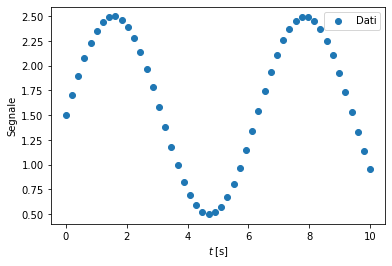

In [35]:
plt.scatter(t, signal, label="Dati")
plt.xlabel("$t \; \mathrm{[s]}$")
plt.ylabel("Segnale") #Funzione continua da misure discrete
plt.legend()
plt.show()

In [36]:
total = simpson(signal, t)
print("Segnale totale:", total)

Segnale totale: 16.839214881269175


#### Sk-learn

Anche il Machine Learning fa parte dei concetti chiave utilizzabili per fittare modelli a dei dati. `Sk-learn` è una delle librerie che permette di utilizzare questi metodi in maniera chiara ed efficace.

In [37]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

np.random.seed(42) #stesso dataset inizio lezione

t = np.linspace(0, 10, 50)
true_slope = 2.5
true_intercept = 1.0

noise = np.random.normal(0, 2, size=len(t))
v = true_slope * t + true_intercept + noise

X = t.reshape(-1, 1)
y = v

In [39]:
#LinearRegression?

In [40]:
model = LinearRegression()
model.fit(X, y)

print("Pendenza:", round(model.coef_[0],2))
print("Intercetta:", round(model.intercept_,2))

Pendenza: 2.38
Intercetta: 1.13


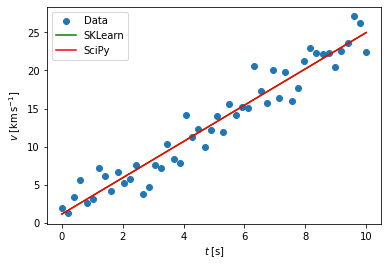

In [42]:
y_pred = model.predict(X)

plt.scatter(t, v, label="Data")
plt.plot(t, y_pred, color="green", label="SKLearn")
plt.plot(x_model, y_model, label="SciPy", color='red')
plt.xlabel("$t \; \mathrm{[s]}$")
plt.ylabel("$v \; \mathrm{[km\,s^{-1}]}$")
plt.legend()
plt.show()

Quando si usa il machine learning, è sempre importante dividere i dati a disposizione in set di training e di test. Per essere ottimale, il modello deve essere sufficientemente generalizzato da performare bene su nuovi dati che non sono stati utilizzati nella fase di training.

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [44]:
model_split = LinearRegression()
model_split.fit(X_train, y_train);

In [45]:
score = model_split.score(X_test, y_test)
print("Test score:", score)

Test score: 0.9313009628366635


Non esiste solo il fit lineare ed è possibile valutare quale sia il miglior modello, dati i parametri del fit.

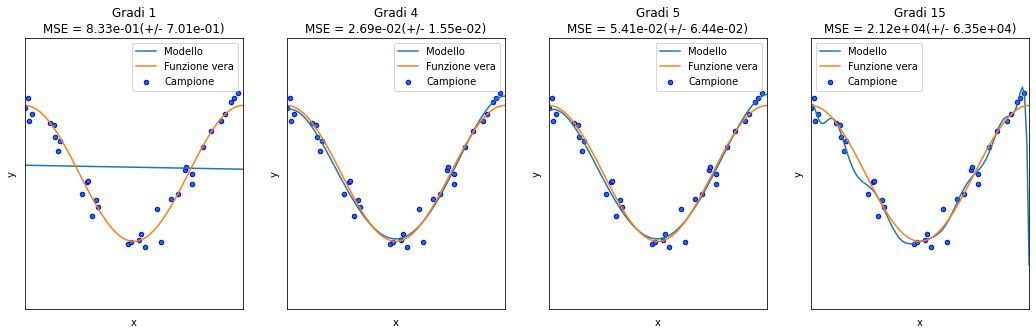

In [46]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

def true_fun(X):
    return np.cos(2.0 * np.pi * X)

np.random.seed(12)

n_samples = 35
degrees = [1, 4, 5, 15] #fit polinomiale

#genero i dati casuali
X = np.sort(np.random.rand(n_samples))
y = true_fun(X) + np.random.randn(n_samples) * 0.1

plt.figure(figsize=(18, 5))

for i in range(len(degrees)):
    ax = plt.subplot(1, len(degrees), i + 1)
    plt.setp(ax, xticks=(), yticks=())

    polynomial_features = PolynomialFeatures(degree=degrees[i],
                                             include_bias=False) #provo a fittare con un polinomio per ognuno dei gradi che ho assunto
    linear_regression = LinearRegression()
    pipeline = Pipeline([("polynomial_features", polynomial_features),
                         ("linear_regression", linear_regression)]) 
    pipeline.fit(X.reshape(-1,1), y)
    # Valutiamo i modelli usando la cross-validation
    scores = cross_val_score(pipeline, X.reshape(-1,1), y,
                             scoring="neg_mean_squared_error", cv=10)

    X_test = np.linspace(0, 1, 100)
    plt.plot(X_test, pipeline.predict(X_test.reshape(-1,1)), label="Modello")
    plt.plot(X_test, true_fun(X_test), label="Funzione vera")
    plt.scatter(X, y, edgecolor='b', s=20, label="Campione")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.xlim((0, 1))
    plt.ylim((-2, 2))
    plt.legend(loc="best")
    plt.title("Gradi {}\nMSE = {:.2e}(+/- {:.2e})".format(
        degrees[i], -scores.mean(), scores.std()))